# 3. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* Use the **logistic regression**.
* Three different **validation methodologies** used to tune hyperparameters, discussing the pros and cons of each.
* **Confusion matrices** for your models, and associated comments.
 * Evaluate your models using the following metrics and provide associated comments for each:
   - **ROC curve**
   - **precision-recall curve**
   - **F1 score**
   - **accuracy**
   - **recall**
   - **precision**
* A discussion of which **performance metric** is most relevant for the evaluation of your models.

Please remember to provide associated comments for each metric; it is not enough to just provide the metric values.

In [21]:
#importing and splitting the data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)
data = pd.read_csv('secondary_data.csv')
from sklearn.model_selection import train_test_split
X = data.drop(columns=["class"])
y = data["class"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_val_data = X_train_val.copy()
train_val_data['class'] = y_train_val.copy()


In [22]:
# handling of missing values TODO

train_val_data.isnull().sum()
missing_percent = train_val_data.isnull().mean() * 100
print("missing_percent")
print(missing_percent)
all = y_train_val.value_counts(normalize=True) * 100
print("all")
print(all)

rooted_stats = train_val_data[train_val_data['stem-root'].notna()]['class'].value_counts(normalize=True) * 100
print("stem-root")
print(rooted_stats)

analysis = train_val_data.groupby('stem-root')['class'].value_counts(normalize=True).unstack() * 100
print("analysis stem-root")
print(analysis)

spore_print_color = train_val_data[train_val_data['spore-print-color'].notna()]['class'].value_counts(normalize=True) * 100
print("spore-print-color")
display(spore_print_color)

analysis = train_val_data.groupby('spore-print-color')['class'].value_counts(normalize=True).unstack() * 100
print("analysis spore-print-color")
print(analysis)

veil_type = train_val_data[train_val_data['veil-type'].notna()]['class'].value_counts(normalize=True) * 100
print("veil-type")
display(veil_type)

analysis = train_val_data.groupby('veil-type')['class'].value_counts(normalize=True).unstack() * 100
print("analysis veil-type")
print(analysis)

veil_color = train_val_data[train_val_data['veil-color'].notna()]['class'].value_counts(normalize=True) * 100
print("veil-color")
display(veil_color) 

analysis = train_val_data.groupby('veil-color')['class'].value_counts(normalize=True).unstack() * 100
print("analysis veil-color")
print(analysis)

stem_surface = train_val_data[train_val_data['stem-surface'].notna()]['class'].value_counts(normalize=True) * 100
print("stem-surface")
display(stem_surface)

analysis = train_val_data.groupby('stem-surface')['class'].value_counts(normalize=True).unstack() * 100
print("analysis stem-surface")
print(analysis)








missing_percent
cap-diameter             0.000000
cap-shape                0.000000
cap-surface             23.094873
cap-color                0.000000
does-bruise-or-bleed     0.000000
gill-attachment         16.096612
gill-spacing            40.976359
gill-color               0.000000
stem-height              0.000000
stem-width               0.000000
stem-root               84.333231
stem-surface            62.405076
stem-color               0.000000
veil-type               94.753863
veil-color              87.900931
has-ring                 0.000000
ring-type                3.962747
spore-print-color       89.636680
habitat                  0.000000
season                   0.000000
class                    0.000000
dtype: float64
all
class
p    55.490738
e    44.509262
Name: proportion, dtype: float64
stem-root
class
p    62.581657
e    37.418343
Name: proportion, dtype: float64
analysis stem-root
class              e           p
stem-root                       
b          67.3421

class
p    72.150899
e    27.849101
Name: proportion, dtype: float64

analysis spore-print-color
class                       e           p
spore-print-color                        
g                  100.000000         NaN
k                   16.646849   83.353151
n                         NaN  100.000000
p                   27.992087   72.007913
r                         NaN  100.000000
u                         NaN  100.000000
w                   58.659794   41.340206
veil-type


class
p    66.835739
e    33.164261
Name: proportion, dtype: float64

analysis veil-type
class              e          p
veil-type                      
u          33.164261  66.835739
veil-color


class
p    57.215361
e    42.784639
Name: proportion, dtype: float64

analysis veil-color
class                e           p
veil-color                        
e                  NaN  100.000000
k                  NaN  100.000000
n                  NaN  100.000000
u                  NaN  100.000000
w            48.392979   51.607021
y           100.000000         NaN
stem-surface


class
p    62.998857
e    37.001143
Name: proportion, dtype: float64

analysis stem-surface
class                 e           p
stem-surface                       
f                   NaN  100.000000
g                   NaN  100.000000
h                   NaN  100.000000
i             36.306640   63.693360
k             32.992126   67.007874
s             58.597938   41.402062
t             47.273589   52.726411
y             32.089363   67.910637


In [23]:
X_train_val=X_train_val.drop(columns=["veil-type"])
X_train_val= X_train_val.fillna('missing')

Text(0.5, 1.0, 'stem-width')

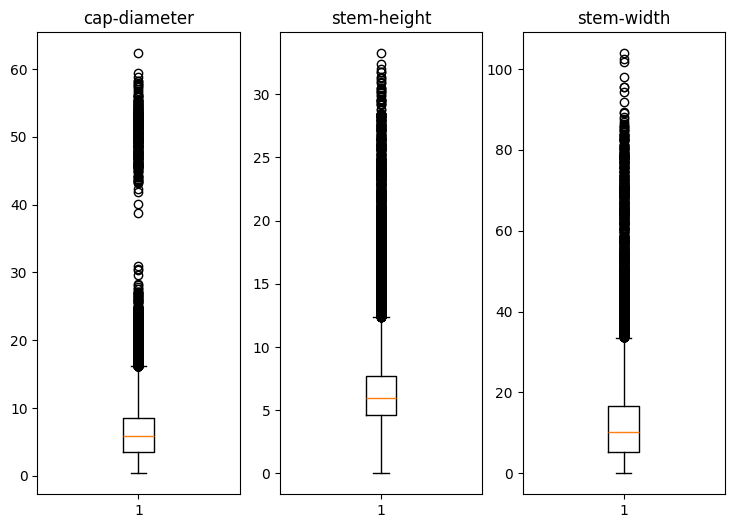

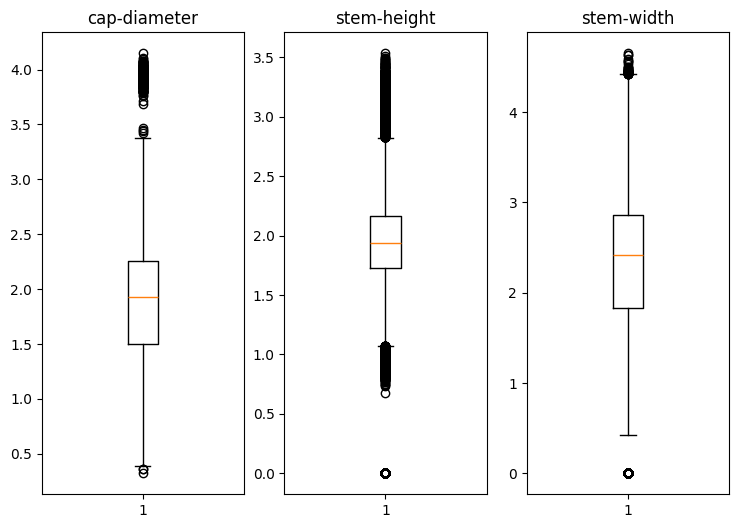

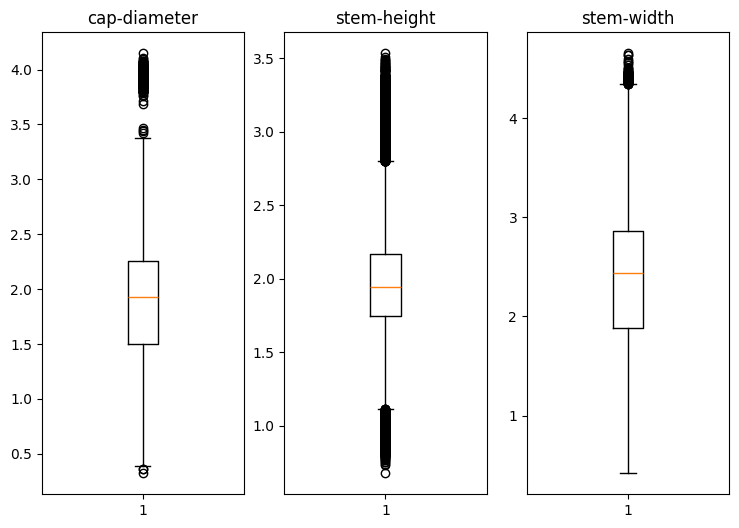

In [24]:
# outliers

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(train_val_data["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(train_val_data["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(train_val_data["stem-width"])
plt.title("stem-width")

X_train_val["cap-diameter"] = X_train_val["cap-diameter"].apply(lambda x: np.log1p(x))
X_train_val["stem-height"] = X_train_val["stem-height"].apply(lambda x: np.log1p(x))
X_train_val["stem-width"] = X_train_val["stem-width"].apply(lambda x: np.log1p(x))

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(X_train_val["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(X_train_val["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(X_train_val["stem-width"])
plt.title("stem-width")

# zeros = X_train_val[(X_train_val['stem-width']==0)]
# print(zeros)
# zeros2 = X_train_val[(X_train_val['stem-height']==0)]
# print(zeros2)

X_train_val['stem-height'] = X_train_val['stem-height'].replace(0, np.nan)
X_train_val['stem-width'] = X_train_val['stem-width'].replace(0, np.nan)

X_train_val['stem-height'] = X_train_val['stem-height'].fillna(X_train_val['stem-height'].median())
X_train_val['stem-width'] = X_train_val['stem-width'].fillna(X_train_val['stem-width'].median())

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(X_train_val["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(X_train_val["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(X_train_val["stem-width"])
plt.title("stem-width")




In [25]:
# one-hot encoding
from sklearn.preprocessing import LabelEncoder
X_train_val = pd.get_dummies(X_train_val, columns=["cap-shape", "cap-surface", "cap-color", "does-bruise-or-bleed", "gill-attachment", "gill-spacing", "gill-color", "stem-root", "stem-surface", "stem-color", "veil-color", "has-ring", "ring-type", "spore-print-color", "habitat", "season"], drop_first=True)
le = LabelEncoder()
y_train_val = le.fit_transform(y_train_val)
X_train_val.head()

train_val_data = X_train_val.copy()
train_val_data['class'] = y_train_val.copy()


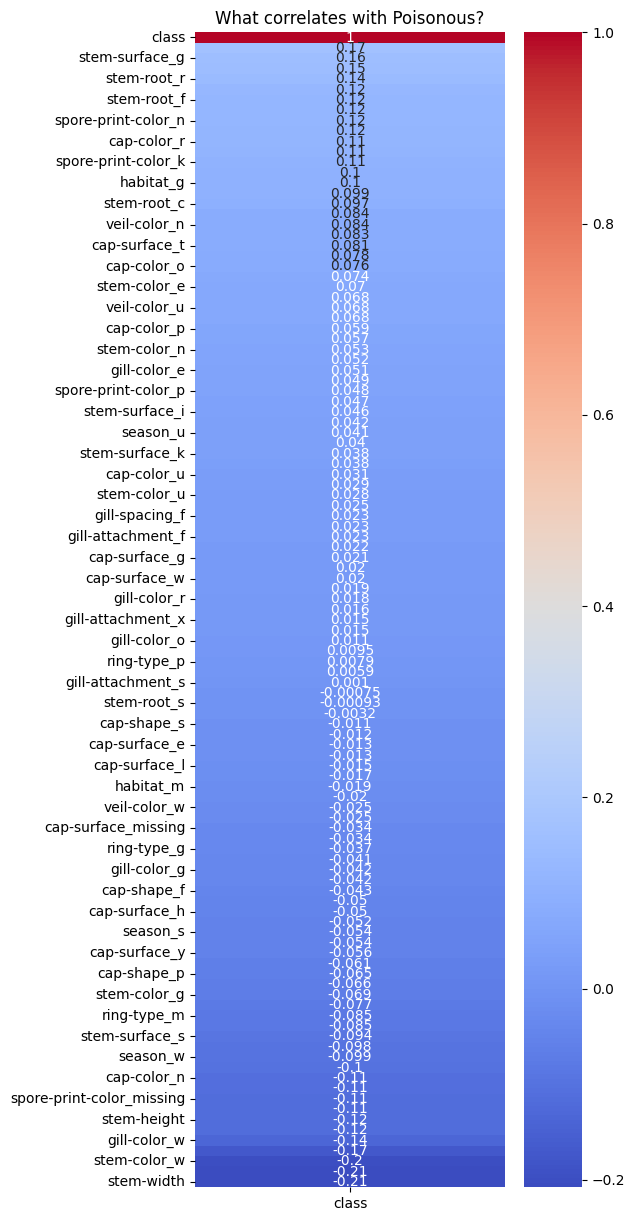

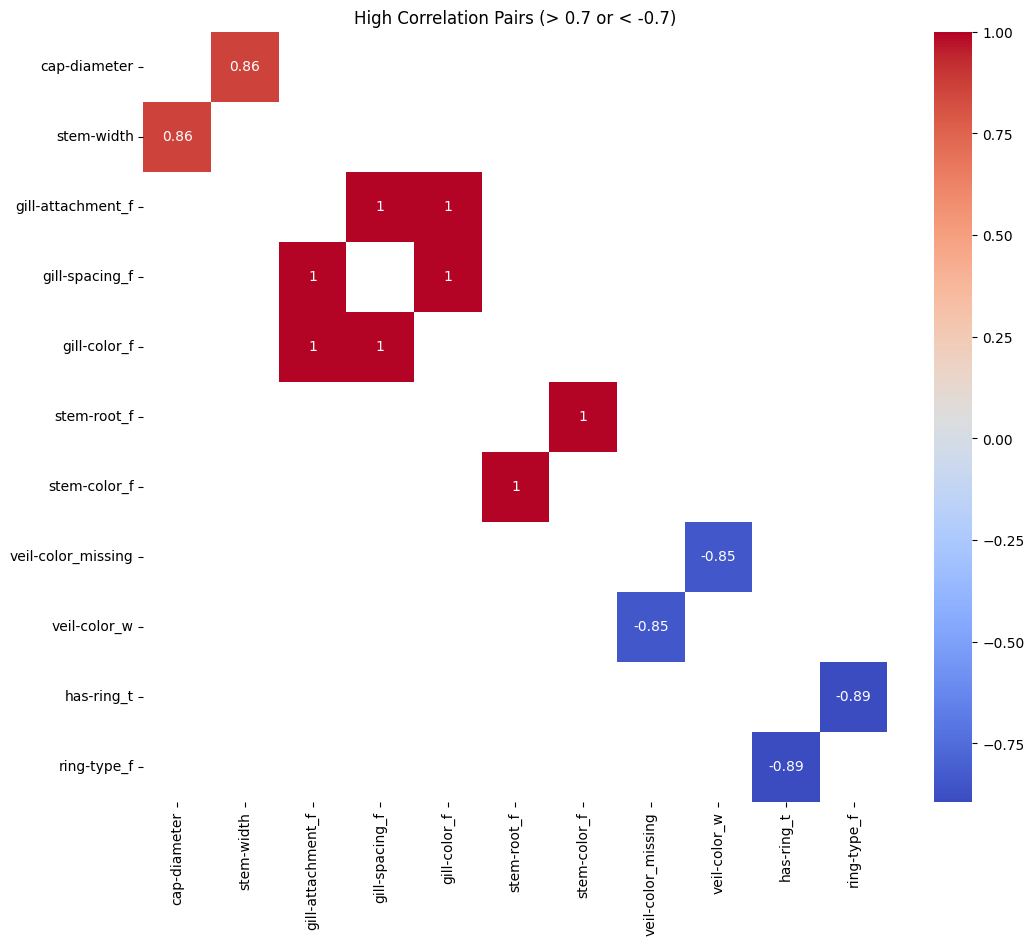

In [26]:
# correlation 

target_corr = train_val_data.corr()[['class']].sort_values(by='class', ascending=False)

plt.figure(figsize=(5, 15))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("What correlates with Poisonous?")
plt.show()

corr = train_val_data.corr()

mask_self = np.eye(corr.shape[0]) == 0
corr_no_diag = corr.where(mask_self)

filtered_corr = corr_no_diag[((corr_no_diag >= 0.7) | (corr_no_diag <= -0.7))]

filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, 
            annot=True, 
            cmap="coolwarm", 
           )

plt.title("High Correlation Pairs (> 0.7 or < -0.7)")
plt.show()

In [27]:
outliers = train_val_data[(train_val_data['has-ring_t'] == 1) & (train_val_data['ring-type_f'] == 1)]
print(f"Number of 'weird' mushrooms: {len(outliers)}")
print(outliers['class'].value_counts())

Number of 'weird' mushrooms: 1943
class
1    1668
0     275
Name: count, dtype: int64


In [28]:
print("Poisonous count for Missing Veil Color:")
print(train_val_data[train_val_data['veil-color_missing'] == 1]['class'].value_counts(normalize=True))

print("\nPoisonous count for White Veil Color:")
print(train_val_data[train_val_data['veil-color_w'] == 1]['class'].value_counts(normalize=True))

Poisonous count for Missing Veil Color:
class
1    0.552534
0    0.447466
Name: proportion, dtype: float64

Poisonous count for White Veil Color:
class
1    0.51607
0    0.48393
Name: proportion, dtype: float64


In [29]:
# correlation continuing

X_train_val = X_train_val.drop(columns=["gill-spacing_f", "gill-color_f", "stem-color_f", "veil-color_missing"])
X_train_val['diameter-and-width'] = X_train_val['cap-diameter'] * X_train_val['stem-width']
X_train_val = X_train_val.drop(columns=["cap-diameter", "stem-width"])
X_train_val.head()

,stem-height,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_missing,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_t,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_missing,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_d,gill-spacing_missing,gill-color_e,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-root_c,stem-root_f,stem-root_missing,stem-root_r,stem-root_s,stem-surface_g,stem-surface_h,stem-surface_i,stem-surface_k,stem-surface_missing,stem-surface_s,stem-surface_t,stem-surface_y,stem-color_e,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,veil-color_k,veil-color_n,veil-color_u,veil-color_w,veil-color_y,has-ring_t,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_missing,ring-type_p,ring-type_r,ring-type_z,spore-print-color_k,spore-print-color_missing,spore-print-color_n,spore-print-color_p,spore-print-color_r,spore-print-color_u,spore-print-color_w,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,diameter-and-width
36219,1.978239,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,3.632181
54188,1.585145,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,4.496821
1609,2.468947,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,6.119637
20481,1.629241,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,3.003897
20546,

In [30]:
# Scaling
from sklearn.preprocessing import StandardScaler
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

scaler = StandardScaler()
X_train[['diameter-and-width', 'stem-height']] = scaler.fit_transform(X_train[['diameter-and-width', 'stem-height']])
X_val[['diameter-and-width', 'stem-height']] = scaler.transform(X_val[['diameter-and-width', 'stem-height']])


In [31]:
# Applying all changes to test set

X_test = X_test.drop(columns=["veil-type"])
X_test = X_test.fillna('missing')

X_test['stem-height'] = X_test['stem-height'].replace(0, np.nan)
X_test['stem-width'] = X_test['stem-width'].replace(0, np.nan)
X_test['stem-height'] = X_test['stem-height'].fillna(X_test['stem-height'].median())
X_test['stem-width'] = X_test['stem-width'].fillna(X_test['stem-width'].median())

X_test = pd.get_dummies(X_test, columns=["cap-shape", "cap-surface", "cap-color", "does-bruise-or-bleed", "gill-attachment", "gill-spacing", "gill-color", "stem-root", "stem-surface", "stem-color", "veil-color", "has-ring", "ring-type", "spore-print-color", "habitat", "season"], drop_first=True)
y_test = le.transform(y_test)

X_test["cap-diameter"] = X_test["cap-diameter"].apply(lambda x: np.log1p(x))
X_test["stem-height"] = X_test["stem-height"].apply(lambda x: np.log1p(x))
X_test["stem-width"] = X_test["stem-width"].apply(lambda x: np.log1p(x))

X_test = X_test.drop(columns=["gill-spacing_f", "gill-color_f", "stem-color_f", "veil-color_missing"])
X_test['diameter-and-width'] = X_test['cap-diameter'] * X_test['stem-width']
X_test = X_test.drop(columns=["cap-diameter", "stem-width"])

X_test[['diameter-and-width', 'stem-height']] = scaler.transform(X_test[['diameter-and-width', 'stem-height']])


